In [1]:
%load_ext autoreload
%autoreload 2
from lost_at_sea import LostAtSea

In [2]:
from math import sqrt
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import random
import seaborn as sns

In [3]:
# Grid Parameters
grid_size_m = 1000
resolution_m = 25
grid_cells = int(grid_size_m / resolution_m)  # 40x40 grid

In [4]:
# Simulate drift paths to fill prior probabilites
# Drift parameters
drift_velocity = np.array([0.05, 0.01])  # cells per step (eastward + slight north)
noise_std = 0.2  # randomness in movement
n_paths = 1000 # Simulate 1000 random walks
n_steps = 480  # Simulating 480 minutes, 1 step per minute
start_pos = np.array([2.0, 7.0])

drift_path_endpoints = LostAtSea.simulate_drift_endpoints(grid_cells, start_pos, n_paths, n_steps, drift_velocity, noise_std)

In [5]:
# Create prior
prior = LostAtSea.create_prior_grid(grid_size_m, resolution_m, drift_path_endpoints)

In [6]:
actual_drift_path, end_pos = LostAtSea.generate_actual_path(grid_cells, start_pos, n_steps)

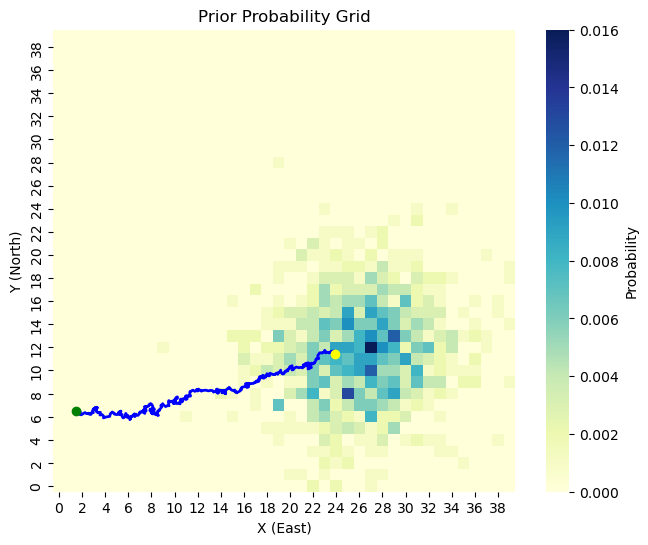

In [7]:
ax = LostAtSea.plot_prior_grid(prior, start_pos, end_pos, actual_drift_path)

Search round 1


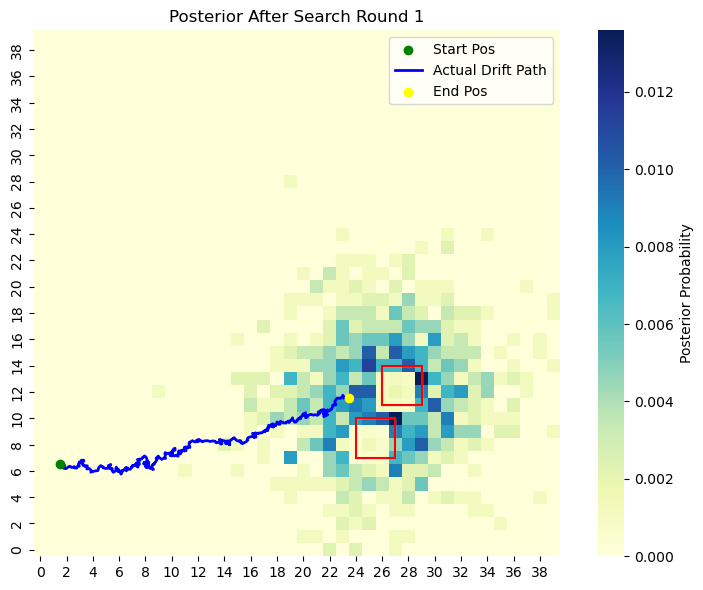

Search round 2


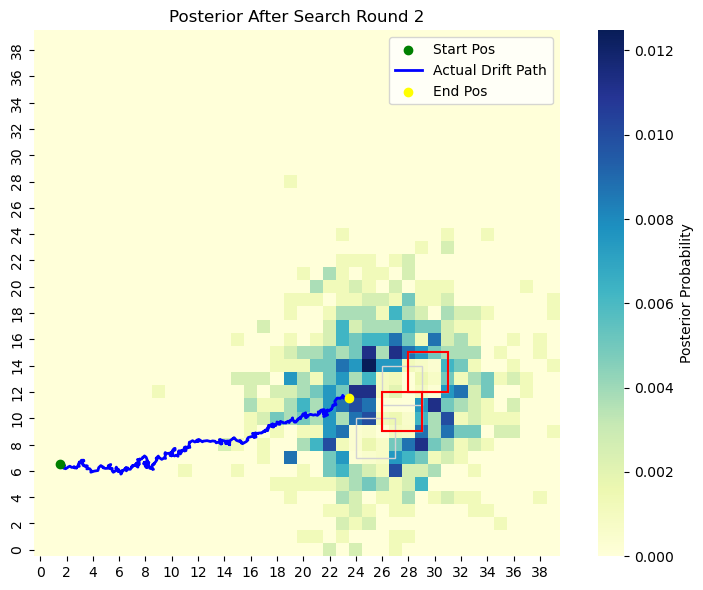

Search round 3
👀 Near miss: (24, 13) close to (24, 12)
👀 Near miss: (25, 13) close to (24, 12)


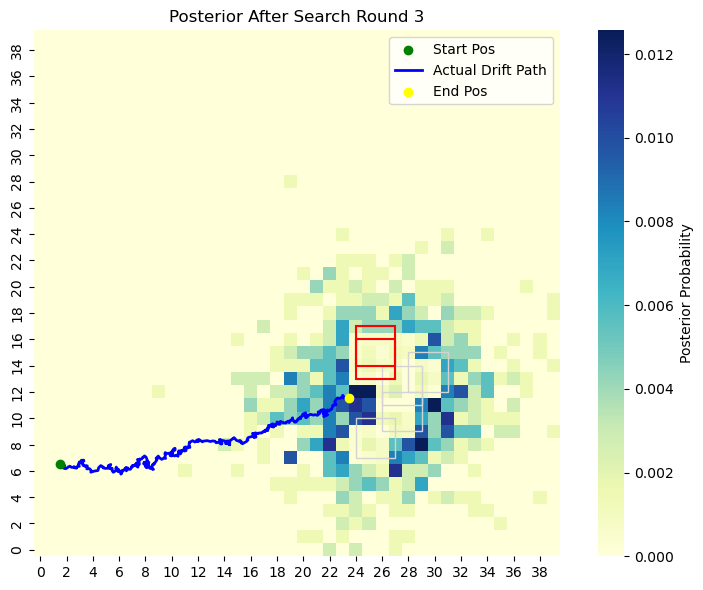

Search round 4

🎯 Target found at [24. 12.] in round 4!


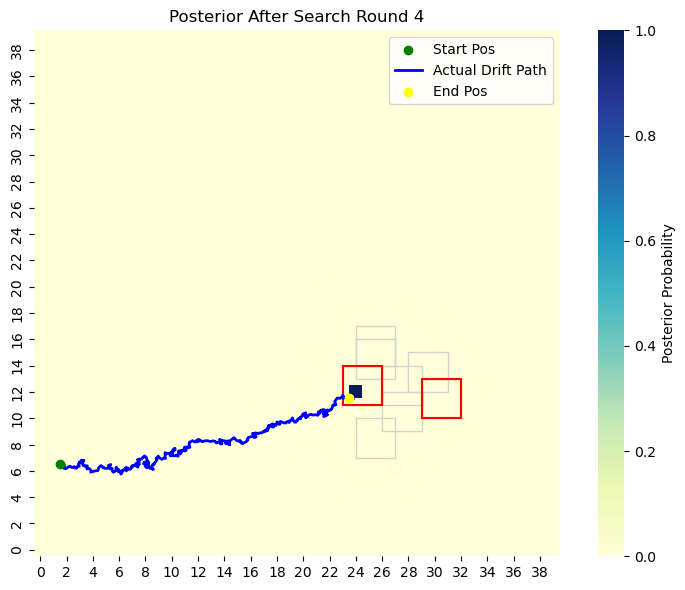

In [8]:
sim_lost_at_sea = LostAtSea()
# Reinitialize posterior from prior
sim_lost_at_sea.posterior_grid_ = prior.copy()

# Keep track of all searched cells
all_searched_cells = []
all_zone_centers = []
radius = 1
rect_width = 2 * radius + 1
rect_height = 2 * radius + 1

# Ensure end_pos is a tuple of ints
end_pos[0] = int(round(end_pos[0]))
end_pos[1] = int(round(end_pos[1]))
end_cell = tuple(map(int, [end_pos[0],end_pos[1]]))
num_rounds = 30
near_miss_thresh = 1

# Run n sequential search rounds
for round_num in range(num_rounds):
    print(f"Search round {round_num + 1}")

    # Select top K cells to search (Zones to search based on bullseye cells as centrepoint of zones)
    searched_cells = LostAtSea.get_top_k_cells_with_radius(sim_lost_at_sea.posterior_grid_, k=2, radius=radius)  # 2 zones of 3x3
    all_searched_cells.extend(searched_cells)

     # Select bullseye zone centres
    zone_centers = LostAtSea.get_top_k_cells(sim_lost_at_sea.posterior_grid_, k=2)
    all_zone_centers.extend(zone_centers)
    all_zone_centers = list(set(all_zone_centers))
    
    # Likelihood update
    sim_lost_at_sea.posterior_grid_ = sim_lost_at_sea.bayesian_update_posterior(searched_cells)
    
    # Visualize updated posterior
    fig, ax = plt.subplots(figsize=(8, 6))
    LostAtSea.plot_prior_grid(sim_lost_at_sea.posterior_grid_, start_pos, end_pos, actual_drift_path, title=f'Posterior After Search Round {round_num + 1}', show_heatmap=False, ax=ax)
  
    # Ensure searched_cells are also tuples of ints
    searched_cells = [tuple(map(int, [cell[1],cell[0]])) for cell in searched_cells]

      # Check for detection
    if end_cell in searched_cells:
        found = random.random() < sim_lost_at_sea.detection_probability  # Simulate detection with 0.9 probability
        if found:
            print(f"\n🎯 Target found at {end_pos} in round {round_num + 1}!")
            sim_lost_at_sea.posterior_grid_[int(end_cell[1]), int(end_cell[0])] = 1.0  # certainty
            LostAtSea.plot_posterior_with_zones(ax, sim_lost_at_sea.posterior_grid_, all_zone_centers, zone_centers, radius, title=f'Posterior After Search Round {round_num + 1}')
            plt.tight_layout()
            plt.show()
            break
        else:
            print(f"🔍 Target was in search area but not detected in round {round_num + 1}.")
    else:
        min_dist = 1000
        closest_cells = []
        for cell in searched_cells:
            if abs(cell[0] - end_cell[0]) <= near_miss_thresh and abs(cell[1] - end_cell[1]) <= near_miss_thresh:
                print(f"👀 Near miss: {cell} close to {end_cell}")
    
    LostAtSea.plot_posterior_with_zones(ax, sim_lost_at_sea.posterior_grid_, all_zone_centers, zone_centers, radius, title=f'Posterior After Search Round {round_num + 1}')
    plt.tight_layout()
    plt.show()
